In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

In [39]:
file_2023 = "DATA TABLE-2023- SALE 50.xlsx"
file_2024 = "DATA TABLE-2024- SALE  51.xlsx"
file_2025 = "DATA TABLE-2025- SALE  46- up to November.xlsx"

df_2023 = pd.read_excel(file_2023, sheet_name="DATA")
df_2024 = pd.read_excel(file_2024, sheet_name="DATA")
df_2025 = pd.read_excel(file_2025, sheet_name="DATA")

df_all = pd.concat([df_2023, df_2024, df_2025], ignore_index=True)
print("df_all:", df_all.shape)

df_all: (1503888, 33)


In [40]:
df_2023.head()

,YEAR,MONTH,BROKER,LOT NO,SALE NO,INV NO,MF,REF,MARK,SALE TYPE,...,BUYER CODE,BUYER NAME,CHEST,CATEGORY,MF/BF,MFREF,FACTORY,ELE1,ELE2,GROUP
0,2023,JAN,AS,1,1,414,MFH,344,GALEWELA SUPER,PUBLIC AUCTION,...,J2,A.F. JONES (EXPORTS) CE,20.0,EX-ESTATE,MF,MF0344,MATALE WEST,Medium,WM,0
1,2023,JAN,AS,2,1,415,MFH,344,GALEWELA SUPER,PUBLIC AUCTION,...,J2,A.F. JONES (EXPORTS) CE,20.0,EX-ESTATE,MF,MF0344,MATALE WEST,Medium,WM,0
2,2023,JAN,AS,4,1,66,MF,62,KELANEIYA & BRAEMAR,PUBLIC AUCTION,...,S080,SUNSHINE CONSUMER LANKA,10.0,EX-ESTATE,MF,MF0062,KELANEIYA,High,WH,0
3,2023,JAN,AS,5,1,248R,MF,1003,SHANNON,PUBLIC AUCTION,...,D332,DILMA CEYLON TEA CO PLC,10.0,EX-ESTATE,MF,MF1003,SHANNON,High,WH,0
4,2023,JAN,AS,7,1,235R,MF,1003,SHANNON,PUBLIC AUCTION,...,U102,UNI WORLD TEAS (PVT) LT,20.0,EX-ESTATE,MF,MF1003,SHANNON,High,WH,0


In [41]:
df_all.head()

,YEAR,MONTH,BROKER,LOT NO,SALE NO,INV NO,MF,REF,MARK,SALE TYPE,...,ELE1,ELE2,GROUP,PLANTATION,COMB. ELEV.,AGRO,CTC/ORTHODOX,DENSITY,CODE,density2
0,2023,JAN,AS,1,1,414,MFH,344,GALEWELA SUPER,PUBLIC AUCTION,...,Medium,WM,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023,JAN,AS,2,1,415,MFH,344,GALEWELA SUPER,PUBLIC AUCTION,...,Medium,WM,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,JAN,AS,4,1,66,MF,62,KELANEIYA & BRAEMAR,PUBLIC AUCTION,...,High,WH,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023,JAN,AS,5,1,248R,MF,1003,SHANNON,PUBLIC AUCTION,...,High,WH,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023,JAN,AS,7,1,235R,MF,1003,SHANNON,PUBLIC AUCTION,...,High,WH,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
df_all.columns.tolist()

['YEAR',
 'MONTH',
 'BROKER',
 'LOT NO',
 'SALE NO',
 'INV NO',
 'MF',
 'REF',
 'MARK',
 'SALE TYPE',
 'GRADE',
 'QTY',
 'PRICE',
 'PRO',
 'TYPE',
 'ELE',
 'BUYER CODE',
 'BUYER NAME',
 'CHEST',
 'CATEGORY',
 'MF/BF',
 'MFREF',
 'FACTORY',
 'ELE1',
 'ELE2',
 'GROUP',
 'PLANTATION',
 'COMB. ELEV.',
 'AGRO',
 'CTC/ORTHODOX',
 'DENSITY',
 'CODE',
 'density2']

In [43]:
# 2) Auto-detect columns

In [44]:
def find_col(df, candidates):
    cols_upper = {c.upper(): c for c in df.columns}
    for cand in candidates:
        if cand.upper() in cols_upper:
            return cols_upper[cand.upper()]
    return None

col_year  = find_col(df_all, ["YEAR", "YR"])
col_sale  = find_col(df_all, ["SALE NO", "SALE_NO", "SALENO", "SALE"])
col_grade = find_col(df_all, ["GRADE", "GRD"])
col_price = find_col(df_all, ["PRICE", "AVG_PRICE", "AVG PRICE", "AVERAGE PRICE"])
col_qty   = find_col(df_all, ["QTY", "QUANTITY", "QTY SOLD", "QTY_SOLD"])
col_ele   = find_col(df_all, ["ELE1", "ELEVATION", "ELEV", "ELE"])

print("Detected columns ->",
      "YEAR:", col_year, "| SALE:", col_sale, "| GRADE:", col_grade,
      "| PRICE:", col_price, "| QTY:", col_qty, "| ELE:", col_ele)

missing = [name for name, v in [("YEAR", col_year), ("SALE", col_sale), ("GRADE", col_grade), ("PRICE", col_price), ("ELE", col_ele)] if v is None]
if missing:
    raise ValueError(f"Missing required columns in your file: {missing}. Print df_all.columns and map manually.")

# Standardize names
df = df_all.rename(columns={
    col_year: "YEAR",
    col_sale: "SALE_NO",
    col_grade: "GRADE",
    col_price: "PRICE",
    col_ele: "ELE1",
    **({col_qty: "QTY"} if col_qty is not None else {})
}).copy()

Detected columns -> YEAR: YEAR | SALE: SALE NO | GRADE: GRADE | PRICE: PRICE | QTY: QTY | ELE: ELE1


In [45]:
# 3) Clean + create week_id + elevation/grade

In [46]:
df["YEAR"] = pd.to_numeric(df["YEAR"], errors="coerce")
df["SALE_NO"] = pd.to_numeric(df["SALE_NO"], errors="coerce")
df["PRICE"] = pd.to_numeric(df["PRICE"], errors="coerce")
if "QTY" in df.columns:
    df["QTY"] = pd.to_numeric(df["QTY"], errors="coerce")

df = df.dropna(subset=["YEAR", "SALE_NO", "GRADE", "PRICE", "ELE1"]).copy()

# week_id = YYYYSS (example: 202401)
df["week_id"] = (df["YEAR"].astype(int) * 100) + (df["SALE_NO"].astype(int))

# elevation mapping
df["elevation"] = df["ELE1"].astype(str).str.strip().str.title()
df["elevation"] = df["elevation"].replace({"Medium": "Mid"})  # important
df["grade"] = df["GRADE"].astype(str).str.strip().str.upper()

In [47]:
# 4) Filter ONLY mid elevation

In [48]:
df_mid = df[df["elevation"] == "Mid"].copy()
print("df_mid:", df_mid.shape)

df_mid: (250027, 36)


In [49]:
# 5) Weekly aggregation (mid × Grade × Week)

In [50]:
if "QTY" in df_mid.columns:
    tmp = df_mid.copy()
    tmp["PQ"] = tmp["PRICE"] * tmp["QTY"]

    weekly_mid = tmp.groupby(["week_id","grade"], as_index=False).agg(
        value=("PQ", "sum"),
        qty_sold=("QTY", "sum")
    )
    weekly_mid["avg_price"] = weekly_mid["value"] / weekly_mid["qty_sold"].replace(0, np.nan)
    weekly_mid = weekly_mid[["week_id","grade","avg_price","qty_sold"]].sort_values(["week_id","grade"])
else:
    weekly_mid = (
        df_mid.groupby(["week_id","grade"], as_index=False)
        .agg(avg_price=("PRICE","mean"))
        .sort_values(["week_id","grade"])
    )

print("weekly_mid:", weekly_mid.shape)
weekly_mid.head()

weekly_mid: (7529, 4)


,week_id,grade,avg_price,qty_sold
0,202301,BM,803.281702,58750.0
1,202301,BOP,1431.499941,17054.0
2,202301,BOP1,1832.772875,11104.0
3,202301,BOP1A,922.696768,36388.0
4,202301,BOPA,1012.187018,23324.0


In [51]:
real_counts_mid = (weekly_mid.dropna(subset=["avg_price"])
                   .groupby("grade")["week_id"]
                   .nunique()
                   .rename("real_weeks")
                   .reset_index())

print("real_counts_mid sample:")
print(real_counts_mid.sort_values("real_weeks").head(20))

real_counts_mid sample:
          grade  real_weeks
271         YH2           1
191      ORGBTD           1
197   ORGBTFGS1           1
198     ORGBTFP           1
200    ORGBTOP1           1
62   EMERAL-TIP           1
205  ORGENJFBD1           1
118       GTGPS           1
186     ORGBOPF           1
55         CSOP           1
53        CS OP           1
52   CONV BT DU           1
206  ORGENJGTFG           1
209  ORGFBTBOP1           1
48   CGTSPHYSON           1
46        CGTSH           1
211  ORGFBTDUST           1
54       CSFNGS           1
185      ORGBOP           1
183  ORFTBTBOP1           1


In [52]:
# 6) Build a REAL calendar of sale weeks (no fake weeks between years)

In [53]:
cal_mid = (weekly_mid[["week_id"]]
           .drop_duplicates()
           .assign(YEAR=lambda d: (d["week_id"] // 100).astype(int),
                   SALE=lambda d: (d["week_id"] % 100).astype(int))
           .sort_values(["YEAR", "SALE"])
           .reset_index(drop=True))

cal_mid["t"] = np.arange(len(cal_mid))

start_date = pd.Timestamp(f"{cal_mid['YEAR'].min()}-01-05")  # arbitrary start
cal_mid["date"] = start_date + pd.to_timedelta(cal_mid["t"], unit="W")


cal_mid.head()

,week_id,YEAR,SALE,t,date
0,202301,2023,1,0,2023-01-05
1,202302,2023,2,1,2023-01-12
2,202303,2023,3,2,2023-01-19
3,202304,2023,4,3,2023-01-26
4,202305,2023,5,4,2023-02-02


In [54]:
# 7) Build a grade series aligned to the calendar (fills missing)

In [55]:
def build_mid_series(weekly_mid, grade, cal_mid):
    g = weekly_mid[weekly_mid["grade"] == grade].copy()
    g = g.merge(cal_mid[["week_id","date"]], on="week_id", how="right").sort_values("date")

    # No leakage style fill (ffill then bfill at start)
    g["avg_price"] = g["avg_price"].ffill().bfill()

    y = g.set_index("date")["avg_price"].astype(float)
    return y

In [56]:
# 8) Safe metrics (never crash on NaN)

In [57]:
def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) == 0:
        return np.nan, np.nan, np.nan

    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mape = float(np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-6, None))) * 100)
    return mae, rmse, mape

In [58]:
# 9) Fit SARIMAX for one grade series (stable indexing)

In [59]:
def fit_one_grade_series_fixed_test(
    y,
    test_size=52,
    order=(1,1,1),
    seasonal_order=(1,0,1,52)
):
    y = y.sort_index().astype(float).dropna()
    if len(y) <= test_size + 10:
        return None

    y_train = y.iloc[:-test_size]
    y_test  = y.iloc[-test_size:]

    try:
        model = SARIMAX(
            y_train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False, maxiter=200)

        fc = model.get_forecast(steps=test_size)
        y_pred = pd.Series(fc.predicted_mean.values, index=y_test.index)

        mae, rmse, mape = calc_metrics(y_test.values, y_pred.values)

        return {
            "model": model,
            "y_full": y,
            "y_train": y_train,
            "y_test": y_test,
            "y_pred_test": y_pred,
            "mae": mae,
            "rmse": rmse,
            "mape": mape,
            "order": order,
            "seasonal_order": seasonal_order
        }
    except Exception as e:
        print("Fit failed:", e)
        return None

In [60]:
# 10) Train SARIMAX for ALL grades (mid)

In [61]:
models_mid = {}
rows_mid = []

MIN_REAL_WEEKS = 120
MIN_STD = 5.0
TEST_SIZE = 52

real_weeks_map_mid = dict(zip(real_counts_mid["grade"], real_counts_mid["real_weeks"]))

for grade in sorted(weekly_mid["grade"].dropna().unique()):
    real_weeks = real_weeks_map_mid.get(grade, 0)
    if real_weeks < MIN_REAL_WEEKS:
        continue

    y = build_mid_series(weekly_mid, grade, cal_mid)

    if float(np.nanstd(y.values)) < MIN_STD:
        continue

    info = fit_one_grade_series_fixed_test(y, test_size=TEST_SIZE)
    if info is None or not np.isfinite(info["mae"]):
        continue

    models_mid[grade] = info
    rows_mid.append([grade, real_weeks, info["mae"], info["rmse"], info["mape"], len(info["y_full"]), str(info["seasonal_order"])])
    print(f"[MID] {grade} | real_weeks={real_weeks} | MAE={info['mae']:.2f} RMSE={info['rmse']:.2f} MAPE={info['mape']:.2f}%")

metrics_mid = (pd.DataFrame(rows_mid, columns=["grade","real_weeks","MAE","RMSE","MAPE_%","n_weeks","seasonal_order"])
               .sort_values("MAPE_%"))

metrics_mid.head(30)

[MID] BM | real_weeks=147 | MAE=87.27 RMSE=98.74 MAPE=10.56%
[MID] BOP | real_weeks=147 | MAE=78.75 RMSE=115.91 MAPE=6.47%
[MID] BOP1 | real_weeks=147 | MAE=74.21 RMSE=93.99 MAPE=5.37%
[MID] BOP1A | real_weeks=147 | MAE=103.64 RMSE=113.87 MAPE=11.81%
[MID] BOPA | real_weeks=147 | MAE=37.25 RMSE=44.66 MAPE=3.88%
[MID] BOPF | real_weeks=147 | MAE=42.28 RMSE=53.61 MAPE=4.45%
[MID] BOPFSP | real_weeks=147 | MAE=77.34 RMSE=101.81 MAPE=6.74%
[MID] BOPSP | real_weeks=147 | MAE=81.50 RMSE=97.78 MAPE=6.90%
[MID] BP | real_weeks=147 | MAE=67.99 RMSE=78.25 MAPE=7.44%
[MID] BP1 | real_weeks=147 | MAE=69.04 RMSE=86.45 MAPE=7.36%
[MID] BPS | real_weeks=142 | MAE=89.65 RMSE=117.33 MAPE=12.29%
[MID] BT | real_weeks=147 | MAE=126.97 RMSE=143.38 MAPE=15.45%
[MID] DUST | real_weeks=147 | MAE=33.47 RMSE=39.87 MAPE=4.72%
[MID] DUST1 | real_weeks=147 | MAE=55.40 RMSE=64.03 MAPE=6.55%
[MID] FBOP | real_weeks=147 | MAE=48.40 RMSE=58.95 MAPE=3.70%
[MID] FBOP1 | real_weeks=147 | MAE=114.75 RMSE=130.42 MAPE=10.4

,grade,real_weeks,MAE,RMSE,MAPE_%,n_weeks,seasonal_order
31,PF1,147,29.437997,39.676662,3.173104,147,"(1, 0, 1, 52)"
14,FBOP,147,48.399179,58.952925,3.699970,147,"(1, 0, 1, 52)"
22,FGS1,147,29.390714,34.264530,3.713961,147,"(1, 0, 1, 52)"
4,BOPA,147,37.251755,44.662531,3.880319,147,"(1, 0, 1, 52)"
5,BOPF,147,42.282699,53.610653,4.446418,147,"(1, 0, 1, 52)"
12,DUST,147,33.474450,39.872108,4.715365,147,"(1, 0, 1, 52)"
2,BOP1,147,74.209495,93.986365,5.368810,147,"(1, 0, 1, 52)"
28,PEK,147,76.587913,89.807176,5.911990,147,"(1, 0, 1, 52)"
16,FBOPF,147,68.320191,91.058605,6.443839,147,"(1, 0, 1, 52)"
1,BOP,147,78.746230,115.913775,6.467737,147,"(1, 0, 1, 52)"


In [62]:
# 11) Validation plot (mid) for any grade

In [63]:
def plot_validation_mid(grade):
    info = models_mid[grade]
    y_full = info["y_full"]
    y_test = info["y_test"]
    y_pred = info["y_pred_test"]

    plt.figure(figsize=(12,4))
    plt.plot(y_full.index, y_full.values, color="lightgray", label="Full series (history)")
    plt.plot(y_test.index, y_test.values, linewidth=2, label="Test (actual)")
    plt.plot(y_pred.index, y_pred.values, linewidth=2, label="Test (pred)")
    plt.title(f"MID – {grade} | MAE={info['mae']:.2f} RMSE={info['rmse']:.2f} MAPE={info['mape']:.2f}%")
    plt.xlabel("Week")
    plt.ylabel("Avg Price (LKR)")
    plt.legend()
    plt.tight_layout()
    plt.show()




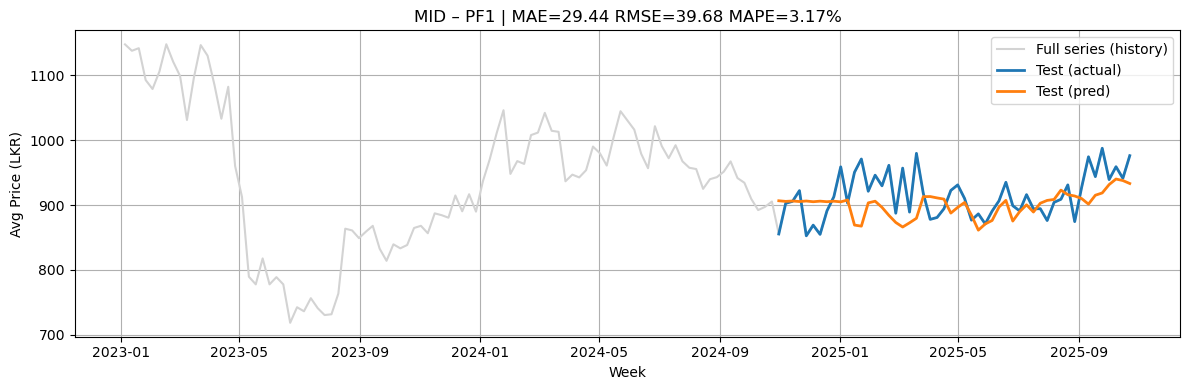

In [64]:
best_grade_mid = metrics_mid.iloc[0]["grade"]
plot_validation_mid(best_grade_mid)

In [65]:
# 12) Residual diagnostics (mid)

In [66]:
def residual_diagnostics_mid(grade, lags=40):
    info = models_mid[grade]
    resid = (info["y_test"] - info["y_pred_test"]).astype(float)

    resid = resid.replace([np.inf, -np.inf], np.nan).dropna()
    if len(resid) < 5:
        print(f"Not enough residual points to plot ACF (n={len(resid)}).")
        return

    max_lags = min(lags, len(resid) - 2, 30)
    if max_lags < 1:
        print(f"Not enough data for ACF (n={len(resid)}).")
        return

    plt.figure(figsize=(12,3))
    plt.plot(resid.index, resid.values)
    plt.title(f"MID – {grade}: Residuals over time (Test) | n={len(resid)}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12,3))
    plot_acf(resid.values, lags=max_lags)
    plt.title(f"MID – {grade}: Residual ACF (Test) | lags={max_lags}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.hist(resid.values, bins=20)
    plt.title(f"MID – {grade}: Residual distribution (Test)")
    plt.tight_layout()
    plt.show()

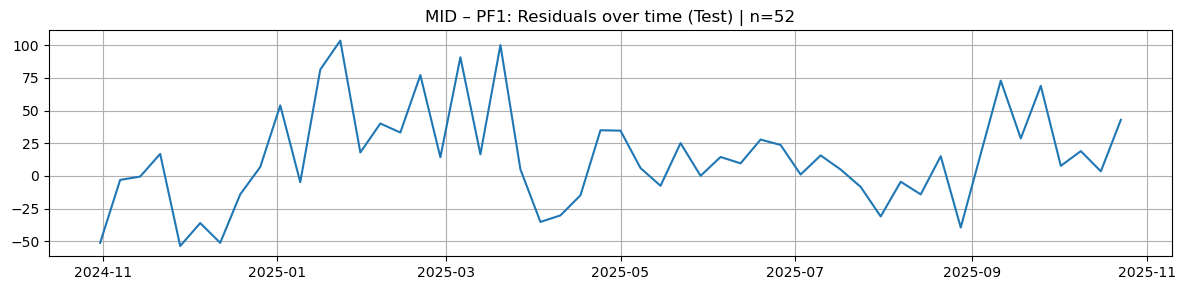

<Figure size 1200x300 with 0 Axes>

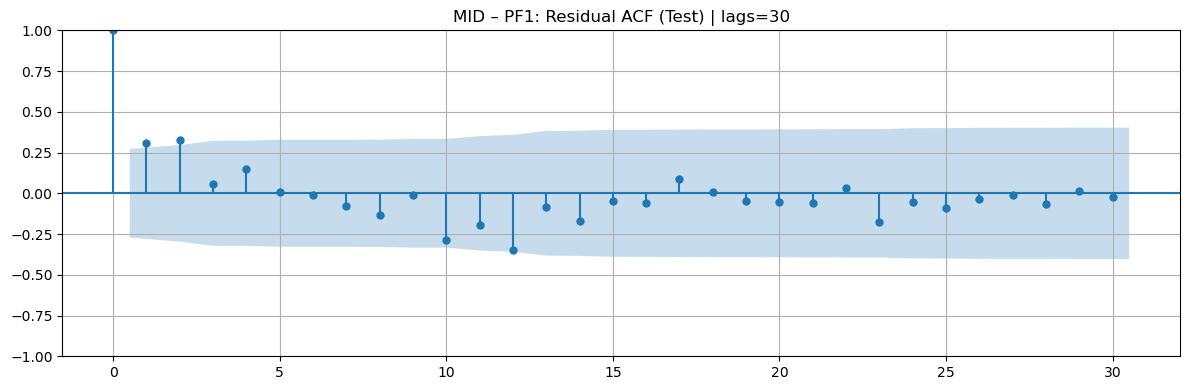

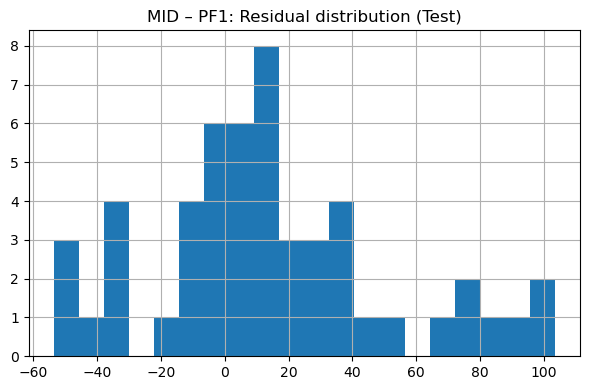

In [67]:
residual_diagnostics_mid(best_grade_mid, lags=40)


In [68]:
# 13) Future forecast plot (mid) + confidence interval

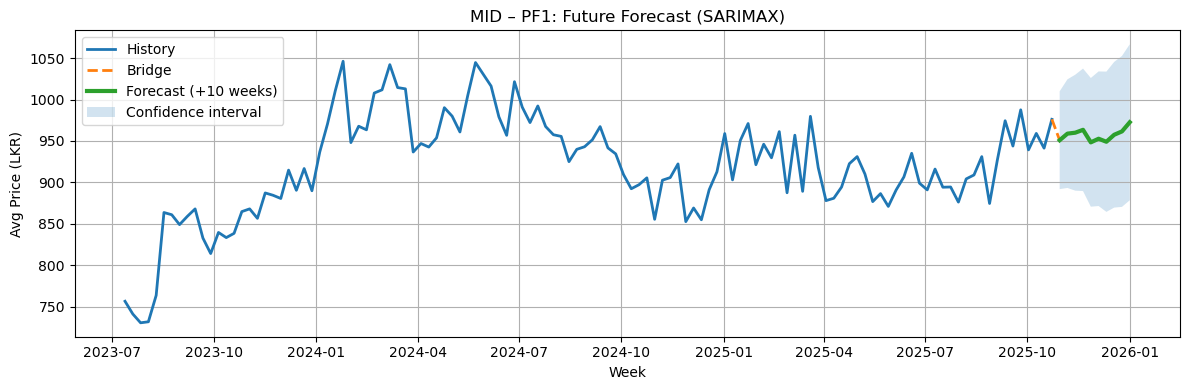

2025-10-30    950.935149
2025-11-06    958.887304
2025-11-13    960.029558
2025-11-20    963.488036
2025-11-27    948.374268
2025-12-04    952.733982
2025-12-11    949.092239
2025-12-18    957.524776
2025-12-25    961.574742
2026-01-01    972.619613
Freq: W-THU, Name: predicted_mean, dtype: float64

In [69]:
def forecast_future_mid(grade, steps=10, show_last=120, connect=True):
    info = models_mid[grade]
    y = info["y_full"]

    model_full = SARIMAX(
        y,
        order=info["order"],
        seasonal_order=info["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False, maxiter=200)

    fc = model_full.get_forecast(steps=steps)
    y_fc = fc.predicted_mean
    ci = fc.conf_int()

    y_plot = y.iloc[-show_last:] if len(y) > show_last else y

    plt.figure(figsize=(12,4))
    plt.plot(y_plot.index, y_plot.values, linewidth=2, label="History")

    if connect and len(y_fc) > 0:
        x0 = y_plot.index[-1]
        y0 = y_plot.iloc[-1]
        x1 = y_fc.index[0]
        y1 = y_fc.iloc[0]
        plt.plot([x0, x1], [y0, y1], linestyle="--", linewidth=2, label="Bridge")

    plt.plot(y_fc.index, y_fc.values, linewidth=3, label=f"Forecast (+{steps} weeks)")
    plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2, label="Confidence interval")

    plt.title(f"MID – {grade}: Future Forecast (SARIMAX)")
    plt.xlabel("Week")
    plt.ylabel("Avg Price (LKR)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return y_fc, ci

y_fc_mid, ci_mid = forecast_future_mid(best_grade_mid, steps=10)
y_fc_mid

In [70]:
# 14) Next-week predictions for ALL mid grades

In [71]:
def next_week_predictions_mid(models_mid):
    out = []
    for grade, info in models_mid.items():
        y = info["y_full"]

        model_full = SARIMAX(
            y,
            order=info["order"],
            seasonal_order=info["seasonal_order"],
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False, maxiter=200)

        next_pred = float(model_full.forecast(steps=1).iloc[0])
        next_date = y.index.max() + pd.to_timedelta(1, unit="W")
        out.append([grade, next_date.date(), next_pred])

    return pd.DataFrame(out, columns=["grade","next_week_date","pred_avg_price"]).sort_values("grade")

df_next_mid = next_week_predictions_mid(models_mid)
df_next_mid.head(30)

,grade,next_week_date,pred_avg_price
0,BM,2025-10-30,771.889294
1,BOP,2025-10-30,1233.064293
2,BOP1,2025-10-30,1389.299903
3,BOP1A,2025-10-30,829.387374
4,BOPA,2025-10-30,933.959593
5,BOPF,2025-10-30,968.403934
6,BOPFSP,2025-10-30,1213.110642
7,BOPSP,2025-10-30,1262.658600
8,BP,2025-10-30,852.712244
9,BP1,2025-10-30,1074.154742


In [72]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def ljung_box_test_mid(grade, lags=10):
    info = models_mid[grade]
    resid = (info["y_test"] - info["y_pred_test"]).astype(float).dropna()

    lags = min(lags, len(resid)-2)
    lb = acorr_ljungbox(resid, lags=[lags], return_df=True)
    print(f"{grade} Ljung-Box (lag={lags}) p-value =", float(lb["lb_pvalue"].iloc[0]))

ljung_box_test_mid("BOP1A", lags=10)


BOP1A Ljung-Box (lag=10) p-value = 9.780689019892618e-42


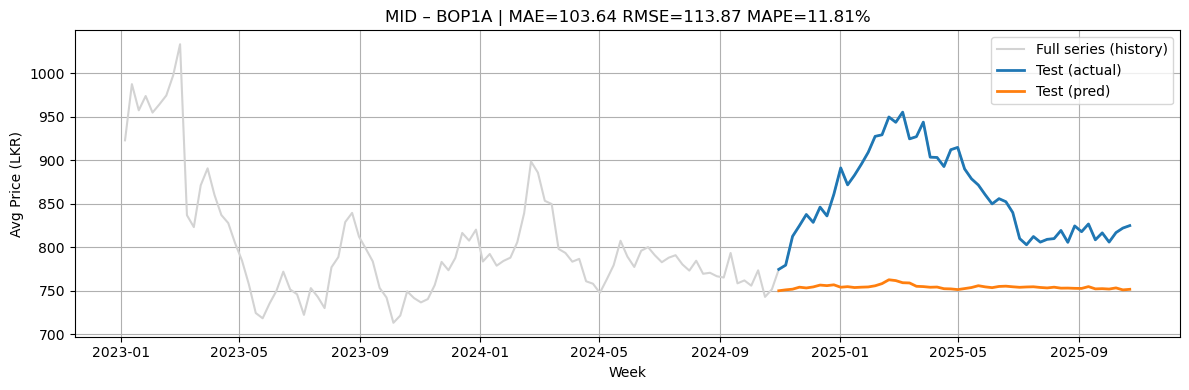

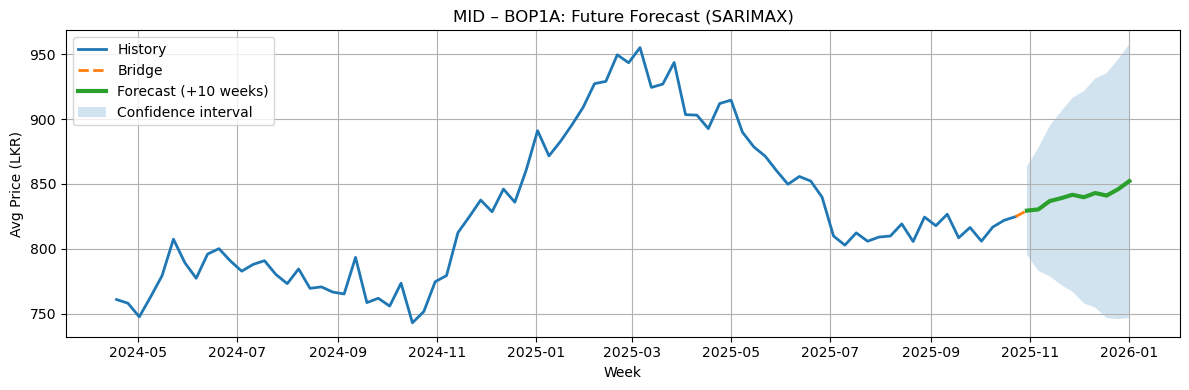

In [73]:
plot_validation_mid("BOP1A")
y_fc, ci = forecast_future_mid("BOP1A", steps=10, show_last=80, connect=True)

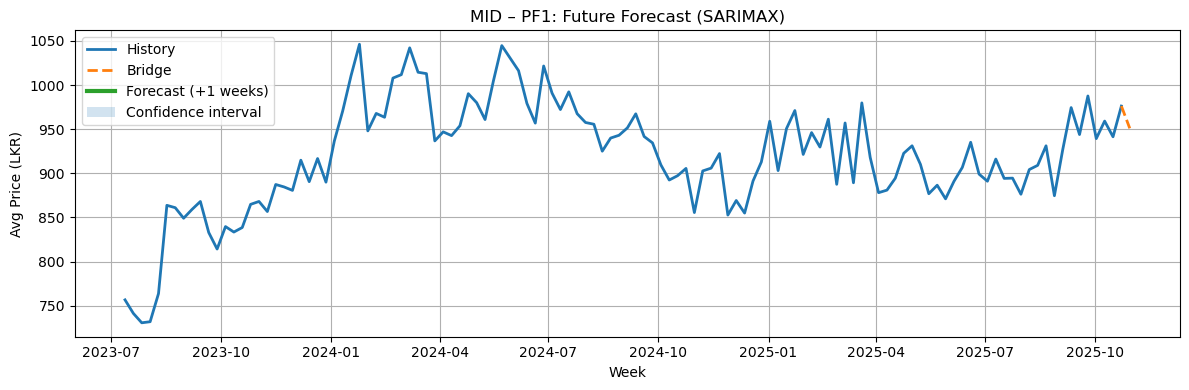

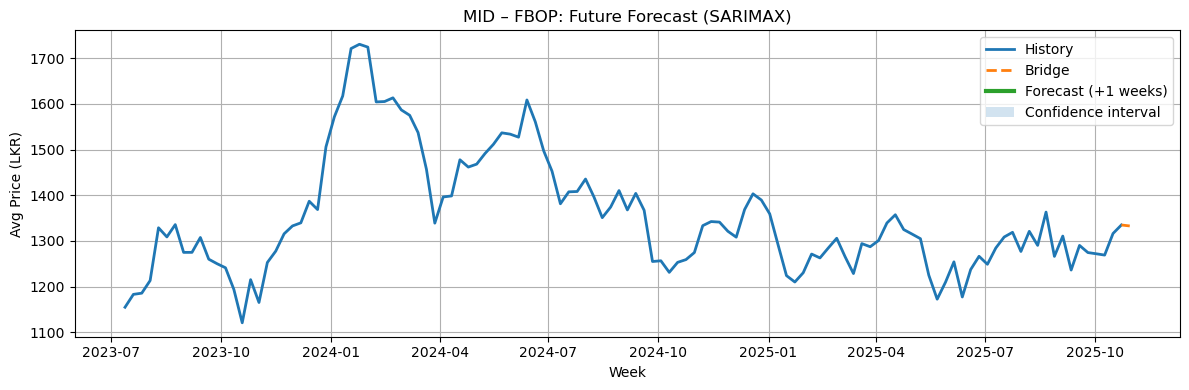

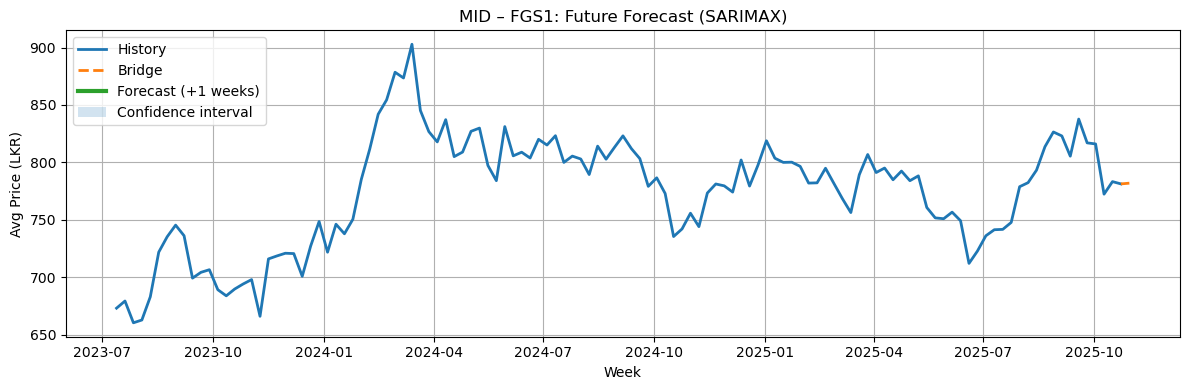

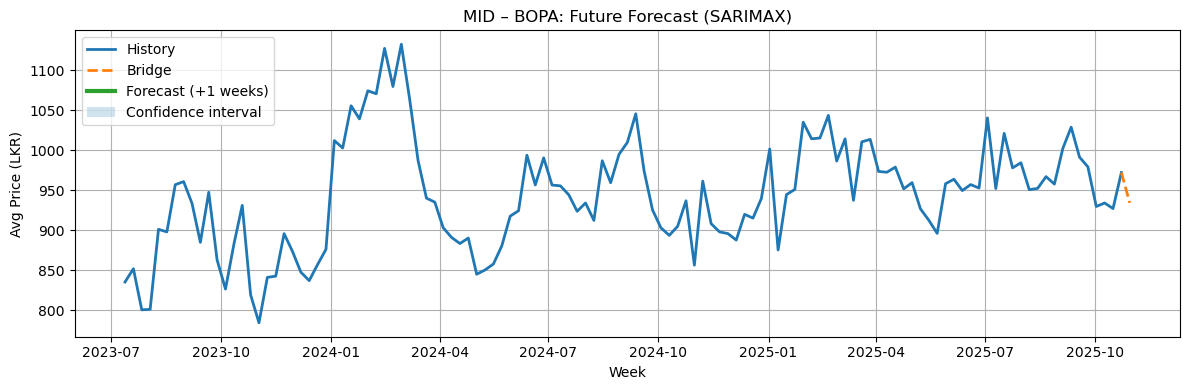

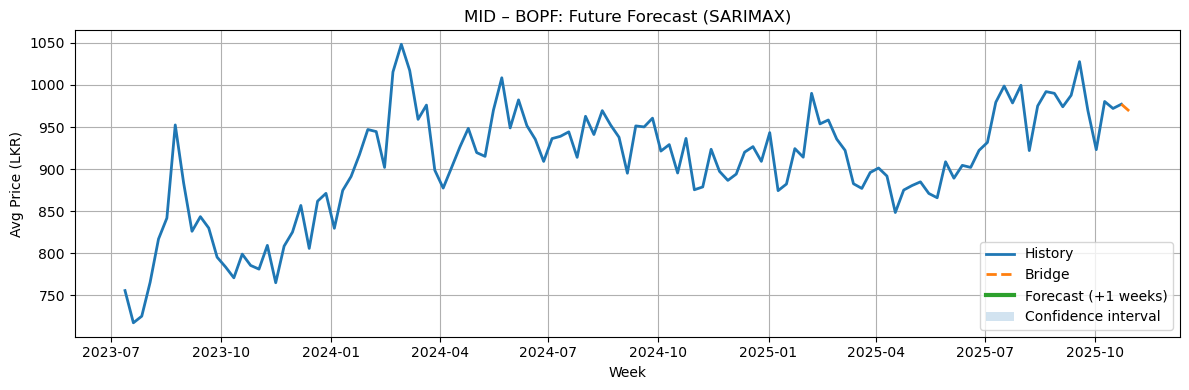

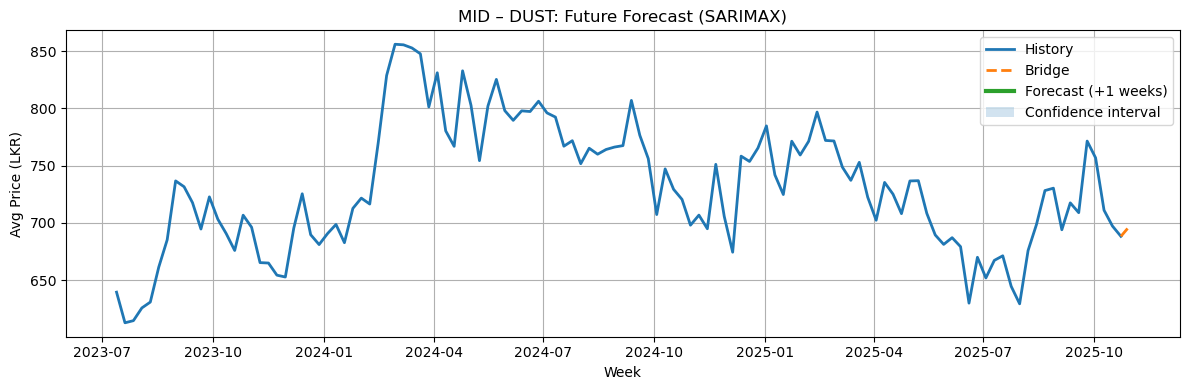

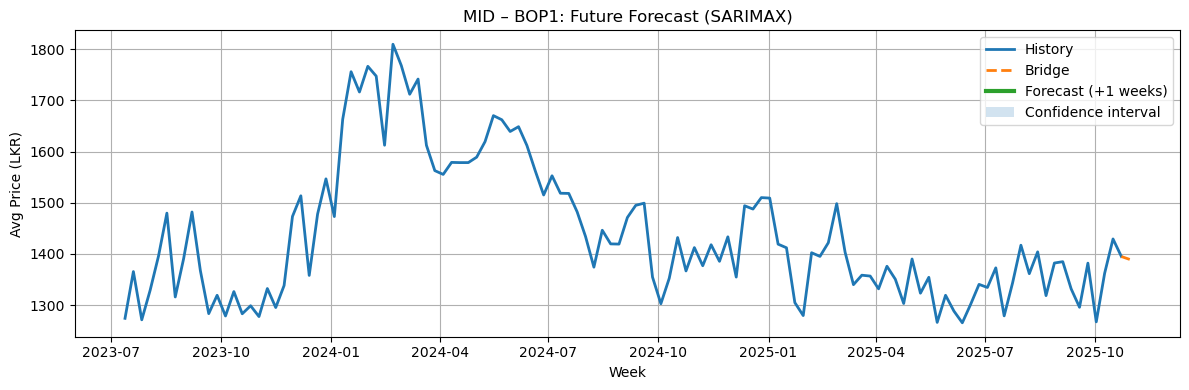

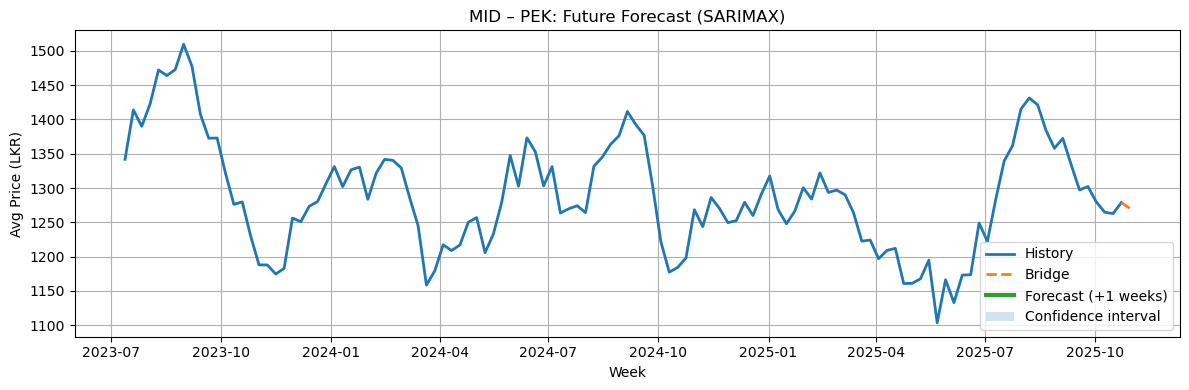

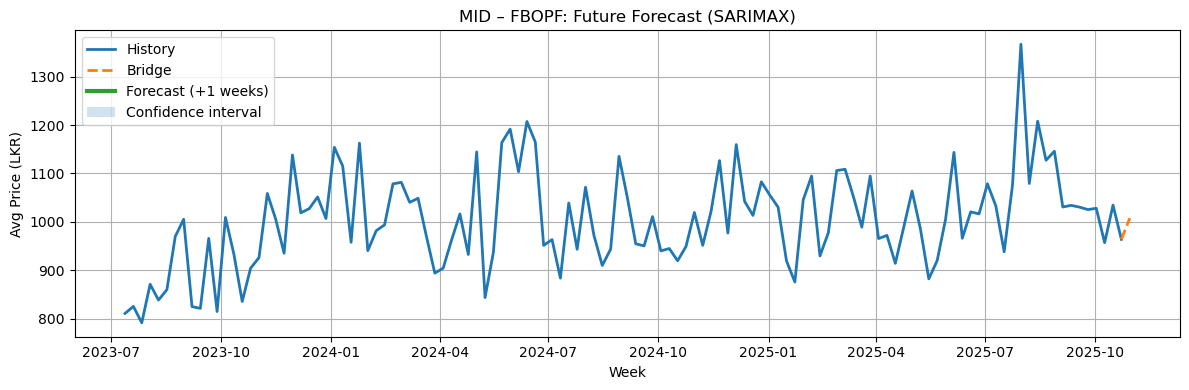

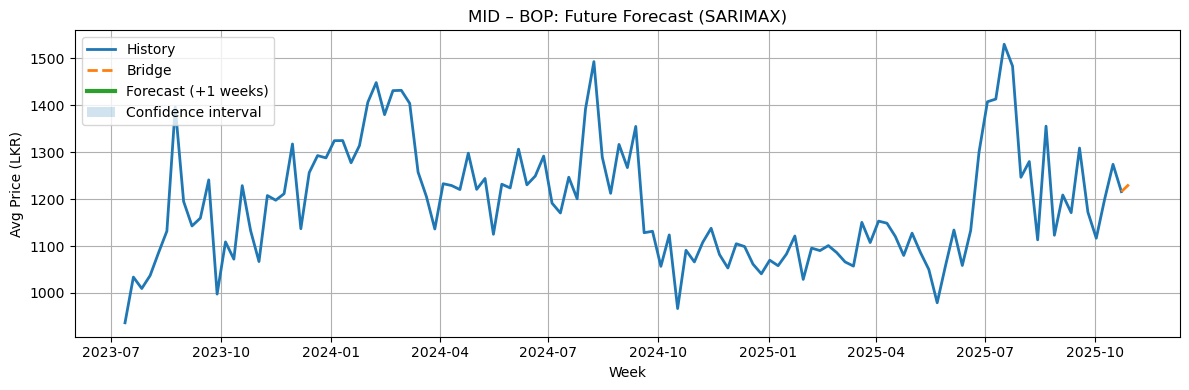

,grade,next_week_pred_price
6,BOP1,1389.299903
1,FBOP,1332.773329
7,PEK,1270.402990
9,BOP,1233.064293
8,FBOPF,1007.671685
4,BOPF,968.403934
0,PF1,950.935149
3,BOPA,933.959593
2,FGS1,781.903191
5,DUST,696.925145


In [74]:
top_grades = metrics_mid.head(10)["grade"].tolist()

preds = []
for g in top_grades:
    y_fc, _ = forecast_future_mid(g, steps=1)
    preds.append([g, float(y_fc.iloc[0])])

pd.DataFrame(preds, columns=["grade","next_week_pred_price"]).sort_values("next_week_pred_price", ascending=False)


In [76]:
import pickle

# Save ALL mid-elevation SARIMAX infos (includes fitted model object inside each grade)
with open("mid_elevation_sarimax_models.pkl", "wb") as f:
    pickle.dump(models_mid, f)

print("Saved all MID-elevation SARIMAX models to mid_elevation_sarimax_models.pkl")


Saved all MID-elevation SARIMAX models to mid_elevation_sarimax_models.pkl
